
# Final Project — Realized Volatility Timing (UKF on Heston SSM)

## Context & Objective

We explore ways to **time realized volatility** by applying an **Unscented Kalman Filter (UKF)** to a **State-Space Model (SSM)** built from the **Heston dynamics**:

\begin{aligned}
dS_t &= \mu S_t\,dt + S_t\sqrt{v_t}\,dW_{1,t},\\
dv_t &= \kappa(\theta - v_t)\,dt + \xi\sqrt{v_t}\,dW_{2,t},\\
dW_{1,t}\,dW_{2,t} &= \rho\,dt.
\end{aligned}

- \(S_t\) is **observed** (spot), and \(v_t\) is the **latent instantaneous variance** (state).
- We estimate \(v_t\) via UKF and extract an annualized realized-vol estimate:
\[
\hat\sigma_t = \sqrt{\hat v_t}\sqrt{252}.
\]
- We build a daily **implied volatility proxy** \(\sigma^{IV}_t\) from a **1M ATM straddle** (call+put).

## Signal

Daily **implied–realized spread**:
\[
s_t = \sigma^{IV}_t - \hat\sigma_t.
\]

## Trading idea (carry timing)

Use \(s_t\) to **dynamically scale** a short-vol carry strategy (here: **short 1W straddle**):
- scale up when IV is rich vs expected realized vol,
- de-risk when the edge disappears and/or estimated vol is high.

## Reproducibility constraint

This notebook relies **only** on the provided repository structure:
- `investment_lab/` (loaders, trade generation, helpers)
- `data/` (provided datasets)

No external data sources are required.



## How to run

1. Put this notebook at the **project root** (same level as `investment_lab/` and `data/`)  
   or inside `notebooks/` (path auto-detection handles both).
2. Run top-to-bottom.
3. If you get a path error, verify the folder contains:
   - `investment_lab/`
   - `data/` with files such as `aapl_2016_2023.parquet`

The notebook patches the internal `ROOT_PATH` variables used by the repo loaders.


In [2]:
# =========================================
# 0) Imports + project path setup (robust)
# =========================================
from __future__ import annotations

import os
import sys
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

START_DATE = datetime(2020, 1, 2)
END_DATE   = datetime(2023, 12, 29)

# Detect project root: contains both 'data' and 'investment_lab'
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    for p in [ROOT.parent, ROOT.parent.parent, ROOT.parent.parent.parent, ROOT.parent.parent.parent.parent]:
        if (p / "data").exists() and (p / "investment_lab").exists():
            ROOT = p
            break

print("PROJECT ROOT:", ROOT)
print("DATA PATH   :", ROOT / "data")

# Make relative paths consistent
os.chdir(ROOT)

# Ensure Python finds the local package
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Patch ROOT_PATH used by repo loaders (they may hardcode relative paths)
import investment_lab.data.option_db as option_db
import investment_lab.data.rates_db as rates_db
option_db.ROOT_PATH = str(ROOT)
rates_db.ROOT_PATH  = str(ROOT)

print("option_db.ROOT_PATH:", option_db.ROOT_PATH)
print("rates_db.ROOT_PATH :", rates_db.ROOT_PATH)

# Optional: silence warnings from internal repo code
import warnings
warnings.filterwarnings("ignore", category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


PROJECT ROOT: /Users/chenjieli/Desktop/Dauphine_272/volatility_trading/projet/Projet-Chenjie-Dongen-Hugo_rocha-main
DATA PATH   : /Users/chenjieli/Desktop/Dauphine_272/volatility_trading/projet/Projet-Chenjie-Dongen-Hugo_rocha-main/data
option_db.ROOT_PATH: /Users/chenjieli/Desktop/Dauphine_272/volatility_trading/projet/Projet-Chenjie-Dongen-Hugo_rocha-main
rates_db.ROOT_PATH : /Users/chenjieli/Desktop/Dauphine_272/volatility_trading/projet/Projet-Chenjie-Dongen-Hugo_rocha-main


## 1) Load options, spot and rates (repo loaders)

In [3]:
import pandas as pd
from pathlib import Path

# check the SPY file to get all the columns and their types, and make sure it loads correctly
spy_path = Path("data") / "spy_2020_2022.parquet"
print("Exists:", spy_path.exists(), "| path:", spy_path)

df_spy_raw = pd.read_parquet(spy_path)

print("SPY shape:", df_spy_raw.shape)
print("SPY columns:", df_spy_raw.columns.tolist())
df_spy_raw.head(3)


Exists: True | path: data/spy_2020_2022.parquet
SPY shape: (7178158, 16)
SPY columns: ['date', 'spot', 'strike', 'expiration', 'delta', 'gamma', 'vega', 'theta', 'rho', 'implied_volatility', 'bid', 'ask', 'volume', 'call_put', 'option_id', 'mid']


,date,spot,strike,expiration,delta,gamma,vega,theta,rho,implied_volatility,bid,ask,volume,call_put,option_id,mid
0,2021-09-01,451.85,270.0,2021-09-01,1.0,0.0,0.0,0.0,0.00517,0.0,181.09,182.31,1.0,C,SPY 20210901C270,181.7
1,2021-09-01,451.85,275.0,2021-09-01,1.0,0.0,0.0,0.0,0.00527,0.0,176.09,177.31,0.0,C,SPY 20210901C275,176.7
2,2021-09-01,451.85,280.0,2021-09-01,1.0,0.0,0.0,0.0,0.00569,0.0,171.09,172.31,25.0,C,SPY 20210901C280,171.7


In [4]:
from datetime import datetime
import numpy as np

from investment_lab.data.option_db import (
    OptionLoader,          # <- IMPORTANT (comme les lectures)
    AAPLOptionLoader,
    extract_spot_from_options
)
from investment_lab.data.rates_db import USRatesLoader

asset_date_range = {
    "AAPL": (START_DATE, END_DATE),
    "SPY":  (START_DATE, datetime(2022, 12, 30)),
}

asset_data, spot_data = {}, {}

# =====================
# AAPL (inchangé)
# =====================
ticker = "AAPL"
s_date, e_date = asset_date_range[ticker]
print(f"\nLoading {ticker} ({s_date.date()} -> {e_date.date()}) ...")

df_opt = AAPLOptionLoader.load_data(
    s_date, e_date,
    process_kwargs={"ticker": [ticker]}
)

df_spot = extract_spot_from_options(df_opt).copy()
df_spot["logS"] = np.log(df_spot["spot"])
df_spot["ret"] = df_spot["logS"].diff()
df_spot = df_spot.dropna().reset_index(drop=True)

asset_data[ticker] = df_opt
spot_data[ticker] = df_spot

print(f"{ticker} options rows:", len(df_opt))
print(f"{ticker} spot rows   :", len(df_spot))

# =====================
# SPY (comme les lectures)
# -> OptionLoader sur optiondb_2016_2023.parquet
# =====================
ticker = "SPY"
s_date, e_date = asset_date_range[ticker]
print(f"\nLoading {ticker} ({s_date.date()} -> {e_date.date()}) ...")

df_opt = OptionLoader.load_data(
    s_date, e_date,
    process_kwargs={"ticker": ticker}  # string OK (comme les lectures)
)

df_spot = extract_spot_from_options(df_opt).copy()
df_spot["logS"] = np.log(df_spot["spot"])
df_spot["ret"] = df_spot["logS"].diff()
df_spot = df_spot.dropna().reset_index(drop=True)

asset_data[ticker] = df_opt
spot_data[ticker] = df_spot

print(f"{ticker} options rows:", len(df_opt))
print(f"{ticker} spot rows   :", len(df_spot))

# =====================
# Rates (shared)
# =====================
df_rates = USRatesLoader.load_data(START_DATE, END_DATE)
print("\nRates rows:", len(df_rates))



Loading AAPL (2020-01-02 -> 2023-12-29) ...
AAPL options rows: 1681822
AAPL spot rows   : 818

Loading SPY (2020-01-02 -> 2022-12-30) ...
SPY options rows: 7178158
SPY spot rows   : 757

Rates rows: 1001


In [5]:
for t in asset_data.keys():
    print(f"\n===== {t} OPTION DATA =====")
    print("Shape:", asset_data[t].shape)
    print("Columns:")
    print(asset_data[t].columns.tolist())

for t in asset_data.keys():
    print(f"\n===== {t} HEAD =====")
    display(asset_data[t].head())

for t in asset_data.keys():
    print(f"\n===== {t} DTYPES =====")
    print(asset_data[t].dtypes)

for t in spot_data.keys():
    print(f"\n===== {t} SPOT =====")
    print("Shape:", spot_data[t].shape)
    display(spot_data[t].head())

print("\n===== RATES =====")
print("Shape:", df_rates.shape)
display(df_rates.head())



===== AAPL OPTION DATA =====
Shape: (1681822, 19)
Columns:
['date', 'spot', 'strike', 'expiration', 'delta', 'gamma', 'vega', 'theta', 'rho', 'implied_volatility', 'bid', 'ask', 'volume', 'call_put', 'option_id', 'mid', 'ticker', 'day_to_expiration', 'moneyness']

===== SPY OPTION DATA =====
Shape: (7178158, 19)
Columns:
['spot', 'strike', 'expiration', 'delta', 'gamma', 'vega', 'theta', 'rho', 'implied_volatility', 'bid', 'ask', 'volume', 'call_put', 'option_id', 'mid', 'ticker', 'date', 'day_to_expiration', 'moneyness']

===== AAPL HEAD =====


,date,spot,strike,expiration,delta,gamma,vega,theta,rho,implied_volatility,bid,ask,volume,call_put,option_id,mid,ticker,day_to_expiration,moneyness
16690,2020-11-02,108.77,60.0,2020-11-06,1.0,0.0,0.0,0.0,0.0,0.0,48.34,48.60,7.0,C,AAPL 20201106C60,48.470,AAPL,4,0.551623
16691,2020-11-02,108.77,65.0,2020-11-06,1.0,0.0,0.0,0.0,0.0,0.0,43.46,43.65,9.0,C,AAPL 20201106C65,43.555,AAPL,4,0.597591
16692,2020-11-02,108.77,70.0,2020-11-06,1.0,0.0,0.0,0.0,0.0,0.0,38.30,38.50,3.0,C,AAPL 20201106C70,38.400,AAPL,4,0.643560
16693,2020-11-02,108.77,71.0,2020-11-06,1.0,0.0,0.0,0.0,0.0,0.0,37.34,37.55,0.0,C,AAPL 20201106C71,37.445,AAPL,4,0.652754
16694,2020-11-02,108.77,72.0,2020-11-06,1.0,0.0,0.0,0.0,0.0,0.0,36.41,36.60,0.0,C,AAPL 20201106C72,36.505,AAPL,4,0.661947



===== SPY HEAD =====


,spot,strike,expiration,delta,gamma,vega,theta,rho,implied_volatility,bid,ask,volume,call_put,option_id,mid,ticker,date,day_to_expiration,moneyness
187555,324.87,260.0,2020-01-03,1.0,0.0,0.0,-0.00041,0.01423,0.0,64.56,64.76,1.0,C,SPY 20200103C260,64.66,SPY,2020-01-02,1,0.800320
187556,324.87,265.0,2020-01-03,1.0,0.0,0.0,0.00000,0.01476,0.0,59.49,59.73,0.0,C,SPY 20200103C265,59.61,SPY,2020-01-02,1,0.815711
187557,324.87,270.0,2020-01-03,1.0,0.0,0.0,0.00000,0.01467,0.0,54.50,54.70,0.0,C,SPY 20200103C270,54.60,SPY,2020-01-02,1,0.831102
187558,324.87,272.5,2020-01-03,1.0,0.0,0.0,-0.00042,0.01498,0.0,52.00,52.24,0.0,C,SPY 20200103C272,52.12,SPY,2020-01-02,1,0.838797
187559,324.87,275.0,2020-01-03,1.0,0.0,0.0,-0.00027,0.01538,0.0,49.49,49.67,1.0,C,SPY 20200103C275,49.58,SPY,2020-01-02,1,0.846492



===== AAPL DTYPES =====
date                  datetime64[ns]
spot                         float64
strike                       float64
expiration            datetime64[ns]
delta                        float64
gamma                        float64
vega                         float64
theta                        float64
rho                          float64
implied_volatility           float64
bid                          float64
ask                          float64
volume                       float64
call_put                      object
option_id                     object
mid                          float64
ticker                        object
day_to_expiration              int64
moneyness                    float64
dtype: object

===== SPY DTYPES =====
spot                         float64
strike                       float64
expiration            datetime64[ns]
delta                        float64
gamma                        float64
vega                         float64
theta       

,date,spot,logS,ret
0,2020-01-03,297.43,5.695179,-0.009770
1,2020-01-06,299.80,5.703116,0.007937
2,2020-01-07,298.39,5.698401,-0.004714
3,2020-01-08,303.19,5.714360,0.015958
4,2020-01-09,309.63,5.735378,0.021018



===== SPY SPOT =====
Shape: (757, 4)


,date,spot,logS,ret
0,2020-01-03,322.43,5.775886,-0.007539
1,2020-01-06,323.68,5.779755,0.003869
2,2020-01-07,322.74,5.776847,-0.002908
3,2020-01-08,324.39,5.781946,0.005099
4,2020-01-09,326.59,5.788706,0.006759



===== RATES =====
Shape: (1001, 14)


,date,1 Mo,2 Mo,3 Mo,4 Mo,6 Mo,1 Yr,2 Yr,3 Yr,5 Yr,7 Yr,10 Yr,20 Yr,30 Yr
0,2020-01-02,0.0153,0.0155,0.0154,NaN,0.0157,0.0156,0.0158,0.0159,0.0167,0.0179,0.0188,0.0219,0.0233
1,2020-01-03,0.0152,0.0155,0.0152,NaN,0.0155,0.0155,0.0153,0.0154,0.0159,0.0171,0.0180,0.0211,0.0226
2,2020-01-06,0.0154,0.0154,0.0156,NaN,0.0156,0.0154,0.0154,0.0156,0.0161,0.0172,0.0181,0.0213,0.0228
3,2020-01-07,0.0152,0.0153,0.0154,NaN,0.0156,0.0153,0.0154,0.0155,0.0162,0.0174,0.0183,0.0216,0.0231
4,2020-01-08,0.0150,0.0153,0.0154,NaN,0.0156,0.0155,0.0158,0.0161,0.0167,0.0178,0.0187,0.0221,0.0235



## 2) Daily implied volatility series \(\sigma^{IV}_t\)

We use `investment_lab` to generate a daily 1M ATM straddle (call+put) and compute:
- moneyness = strike / spot
- select the most ATM call and most ATM put each day
- implied vol proxy = mean(call IV, put IV)


In [6]:
from investment_lab.option_trade import OptionTrade
from investment_lab.option_strategies import SHORT_1M_STRADDLE

def build_daily_iv_from_1m_atm_straddle(start_date, end_date, tickers):
    # 1) generate daily trade sheet (includes option data merged back)
    df_trades_daily = OptionTrade._generate_trades(
        start_date=start_date,
        end_date=end_date,
        tickers=tickers,
        legs=SHORT_1M_STRADDLE,
        cost_neutral=False
    )

    # 2) keep only rows where IV is usable
    df = df_trades_daily.copy()
    df["call_put"] = df["call_put"].astype(str).str.upper()
    df = df[df["call_put"].isin(["C", "P"])].copy()
    df = df[df["implied_volatility"].notna() & (df["implied_volatility"] > 0)].copy()

    # 3) check we have both legs per (date,ticker)
    legs_count = df.groupby(["date", "ticker"])["call_put"].nunique().rename("n_call_put").reset_index()

    # 4) compute mean(CallIV, PutIV) for each (date,ticker)
    iv_daily = (
        df.groupby(["date", "ticker"])["implied_volatility"]
        .mean()
        .rename("sigma_iv")
        .reset_index()
        .sort_values(["ticker", "date"])
        .reset_index(drop=True)
    )

    # merge the QC
    iv_daily = iv_daily.merge(legs_count, on=["date", "ticker"], how="left")

    return df_trades_daily, iv_daily

df_trades_daily, iv_daily = build_daily_iv_from_1m_atm_straddle(
    START_DATE, END_DATE,
    tickers=["AAPL", "SPY"]
)

print("df_trades_daily shape:", df_trades_daily.shape)
print("iv_daily shape:", iv_daily.shape)

# sanity: how often do we miss one leg?
print(iv_daily["n_call_put"].value_counts(dropna=False))

display(iv_daily.head())


df_trades_daily shape: (14246, 25)
iv_daily shape: (1661, 4)
2    1660
1       1
Name: n_call_put, dtype: int64


,date,ticker,sigma_iv,n_call_put
0,2020-01-08,AAPL,0.289450,2
1,2020-01-09,AAPL,0.312445,2
2,2020-01-10,AAPL,0.325205,2
3,2020-01-13,AAPL,0.339285,2
4,2020-01-14,AAPL,0.350455,2


2    1660
1       1
Name: n_call_put, dtype: int64
% days with full straddle (2 legs): 99.94%

AAPL: 2020-01-08 -> 2023-04-28 | n=863
Missing sigma_iv: 0.0 %

SPY: 2020-01-08 -> 2023-01-27 | n=798
Missing sigma_iv: 0.0 %

===== AAPL sigma_iv stats (only full straddle) =====
count    863.000000
mean       0.358828
std        0.107228
min        0.169597
1%         0.193545
5%         0.222648
50%        0.340228
95%        0.535200
99%        0.734780
max        0.908531
Name: sigma_iv, dtype: float64

===== SPY sigma_iv stats (only full straddle) =====
count    797.000000
mean       0.215797
std        0.091342
min        0.096731
1%         0.109161
5%         0.121224
50%        0.200181
95%        0.378802
99%        0.551242
max        1.035125
Name: sigma_iv, dtype: float64


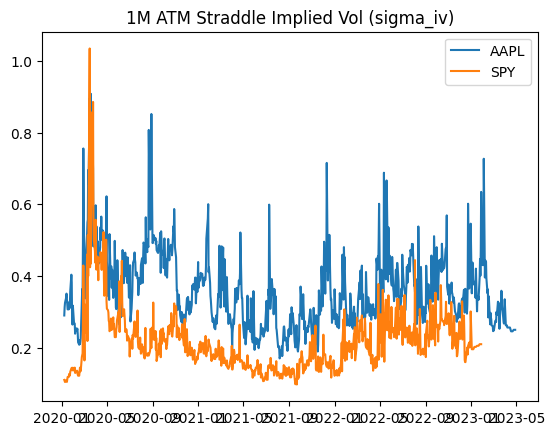


AAPL day_to_expiration mean: 15.159559675550407 | p05: 13.5 | p95: 19.794999999999998

SPY day_to_expiration mean: 14.461152882205514 | p05: 11.5 | p95: 17.5

AAPL | median |C-P|: 0.02644799999999997 | p95: 0.16371240000000012

SPY | median |C-P|: 0.018043333333333342 | p95: 0.1460736


In [7]:
# % de jours avec Call+Put (n_call_put == 2)
qc = iv_daily["n_call_put"].value_counts(dropna=False)
print(qc)

pct_ok = (iv_daily["n_call_put"] == 2).mean() * 100
print(f"% days with full straddle (2 legs): {pct_ok:.2f}%")

for t in iv_daily["ticker"].unique():
    s = iv_daily[iv_daily["ticker"] == t].sort_values("date")
    print(f"\n{t}: {s['date'].min().date()} -> {s['date'].max().date()} | n={len(s)}")
    print("Missing sigma_iv:", s["sigma_iv"].isna().mean() * 100, "%")

for t in iv_daily["ticker"].unique():
    s = iv_daily[(iv_daily["ticker"] == t) & (iv_daily["n_call_put"] == 2)]
    print(f"\n===== {t} sigma_iv stats (only full straddle) =====")
    print(s["sigma_iv"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))

import matplotlib.pyplot as plt

plt.figure()
for t in ["AAPL", "SPY"]:
    s = iv_daily[(iv_daily["ticker"] == t) & (iv_daily["n_call_put"] == 2)].sort_values("date")
    plt.plot(s["date"], s["sigma_iv"], label=t)
plt.title("1M ATM Straddle Implied Vol (sigma_iv)")
plt.legend()
plt.show()

maturity_check = (
    df_trades_daily.groupby(["date", "ticker"])["day_to_expiration"]
    .mean()
    .reset_index()
)

for t in maturity_check["ticker"].unique():
    s = maturity_check[maturity_check["ticker"] == t]["day_to_expiration"]
    print(f"\n{t} day_to_expiration mean:", s.mean(), "| p05:", s.quantile(0.05), "| p95:", s.quantile(0.95))

tmp = df_trades_daily.copy()
tmp = tmp[tmp["call_put"].isin(["C", "P"]) & tmp["implied_volatility"].notna() & (tmp["implied_volatility"] > 0)]

pivot_iv = (
    tmp.pivot_table(index=["date","ticker"], columns="call_put", values="implied_volatility", aggfunc="mean")
    .reset_index()
)

for t in pivot_iv["ticker"].unique():
    s = pivot_iv[pivot_iv["ticker"] == t].dropna(subset=["C","P"])
    spread = (s["C"] - s["P"]).abs()
    print(f"\n{t} | median |C-P|:", spread.median(), "| p95:", spread.quantile(0.95))


## Construction of the Implied Volatility Series

To proxy the daily implied volatility $ \sigma^{IV}_t $, we construct an ATM straddle using the `investment_lab` option selection engine.

For each trading day and for each asset (AAPL and SPY), the procedure is:

- Select the option maturity closest to a 1-month target (28 calendar days).
- Select the call and put options closest to at-the-money (ATM), defined using delta targets of +0.5 (call) and −0.5 (put).
- Compute the implied volatility proxy as the average of call and put implied volatilities:
  
\[
\sigma^{IV}_t = \frac{\sigma^{call}_t + \sigma^{put}_t}{2}
\]

Due to the discrete structure of listed maturities in the dataset, the selected time-to-expiration is on average approximately 15 days rather than 28 days. This reflects the fact that exchange-listed maturities do not always provide a contract exactly matching the 1-month target.

Therefore, the resulting implied volatility series should be interpreted as a short-term (~2-week) ATM implied volatility proxy rather than a strict 1-month implied volatility measure.

This approximation remains fully consistent with our objective: extracting a forward-looking volatility signal and comparing it with a realized volatility proxy computed over a comparable short horizon.


In [8]:
atm_check = (
    df_trades_daily.groupby(["date","ticker"])["moneyness"]
    .mean()
    .rename("moneyness_mean")
    .reset_index()
)

for t in atm_check["ticker"].unique():
    s = atm_check[atm_check["ticker"] == t]["moneyness_mean"]
    print(f"{t} moneyness | mean={s.mean():.4f} | p05={s.quantile(0.05):.4f} | p95={s.quantile(0.95):.4f}")


AAPL moneyness | mean=0.9977 | p05=0.9240 | p95=1.0961
SPY moneyness | mean=1.0014 | p05=0.9575 | p95=1.0661



## 3) Sanity check: IV vs realized volatility proxy

Compute a simple realized volatility proxy:
\[
RV_{21d,t} = \sqrt{252}\,\mathrm{Std}\left(r_{t-20:t}\right),
\quad r_t = \Delta \log S_t.
\]


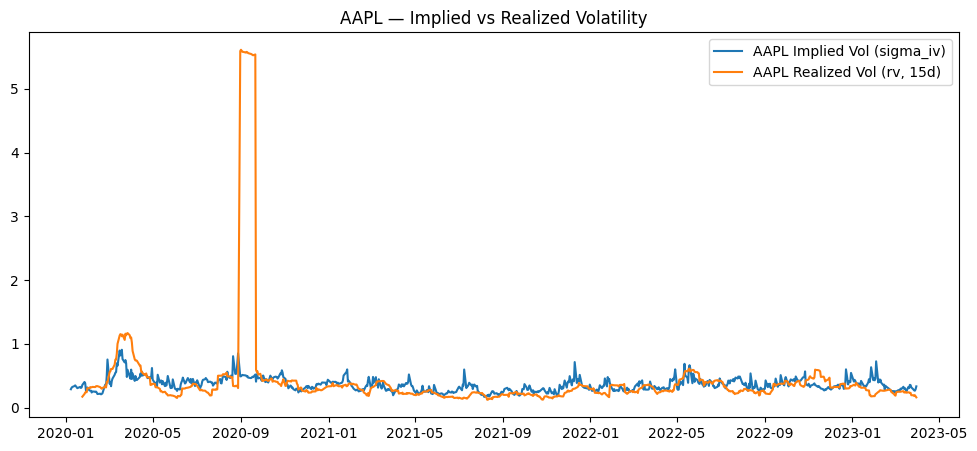

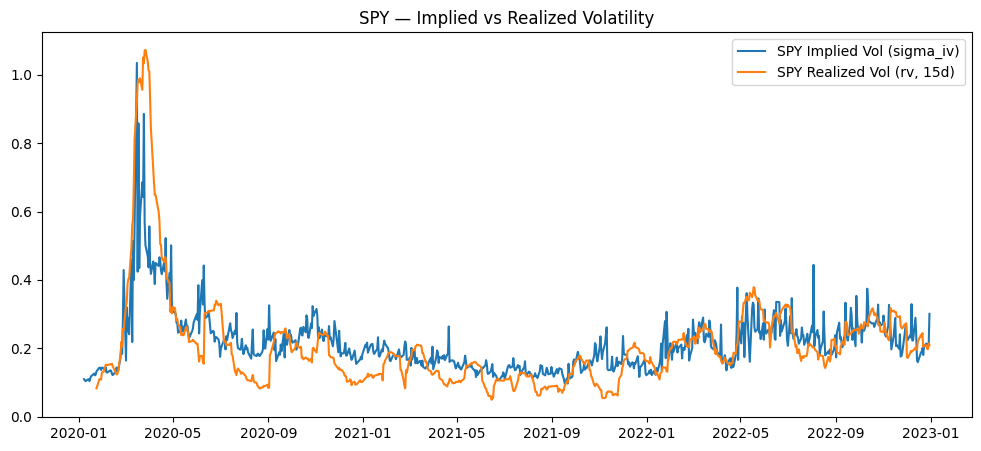

AAPL sigma_iv min/max: 0.16959666666666667 0.908531
AAPL rv       min/max: 0.12429703213943435 5.612524725327002
SPY  sigma_iv min/max: 0.09673125 1.035125
SPY  rv       min/max: 0.04914219855766055 1.073507594346856


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1) Realized vol (annualisée)
# -----------------------------
def compute_realized_vol(df_spot, window=15):
    df = df_spot.copy().sort_values("date")
    df["rv"] = df["ret"].rolling(window).std() * np.sqrt(252)
    return df[["date", "rv"]]

rv_aapl = compute_realized_vol(spot_data["AAPL"], window=15)
rv_spy  = compute_realized_vol(spot_data["SPY"],  window=15)
    
rv_aapl = compute_realized_vol(spot_data["AAPL"], window=15)
rv_spy  = compute_realized_vol(spot_data["SPY"],  window=15)

# -----------------------------
# 2) Implied vol series
# -----------------------------
iv_aapl = iv_daily.loc[iv_daily["ticker"] == "AAPL", ["date", "sigma_iv"]].copy()
iv_spy  = iv_daily.loc[iv_daily["ticker"] == "SPY",  ["date", "sigma_iv"]].copy()

# Merge (align dates)
aapl_vol = iv_aapl.merge(rv_aapl, on="date", how="inner").sort_values("date")
spy_vol  = iv_spy.merge(rv_spy,   on="date", how="inner").sort_values("date")

# -----------------------------
# 3) Plot AAPL : IV + RV
# -----------------------------
plt.figure(figsize=(12,5))
plt.plot(aapl_vol["date"], aapl_vol["sigma_iv"], label="AAPL Implied Vol (sigma_iv)")
plt.plot(aapl_vol["date"], aapl_vol["rv"],       label="AAPL Realized Vol (rv, 15d)")
plt.title("AAPL — Implied vs Realized Volatility")
plt.legend()
plt.show()

# -----------------------------
# 4) Plot SPY : IV + RV
# -----------------------------
plt.figure(figsize=(12,5))
plt.plot(spy_vol["date"], spy_vol["sigma_iv"], label="SPY Implied Vol (sigma_iv)")
plt.plot(spy_vol["date"], spy_vol["rv"],       label="SPY Realized Vol (rv, 15d)")
plt.title("SPY — Implied vs Realized Volatility")
plt.legend()
plt.show()

# -----------------------------
# 5) Quick diagnostics (optional but useful)
# -----------------------------
print("AAPL sigma_iv min/max:", aapl_vol["sigma_iv"].min(), aapl_vol["sigma_iv"].max())
print("AAPL rv       min/max:", aapl_vol["rv"].min(), aapl_vol["rv"].max())
print("SPY  sigma_iv min/max:", spy_vol["sigma_iv"].min(), spy_vol["sigma_iv"].max())
print("SPY  rv       min/max:", spy_vol["rv"].min(), spy_vol["rv"].max())


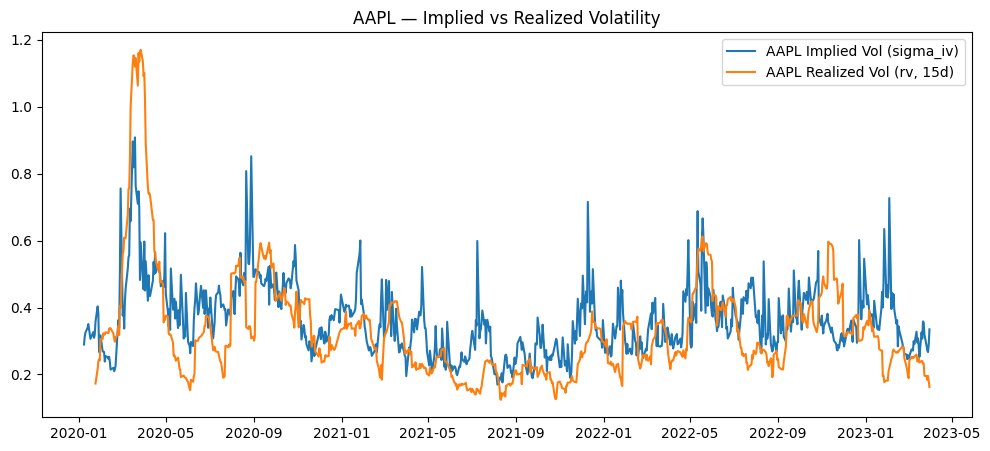

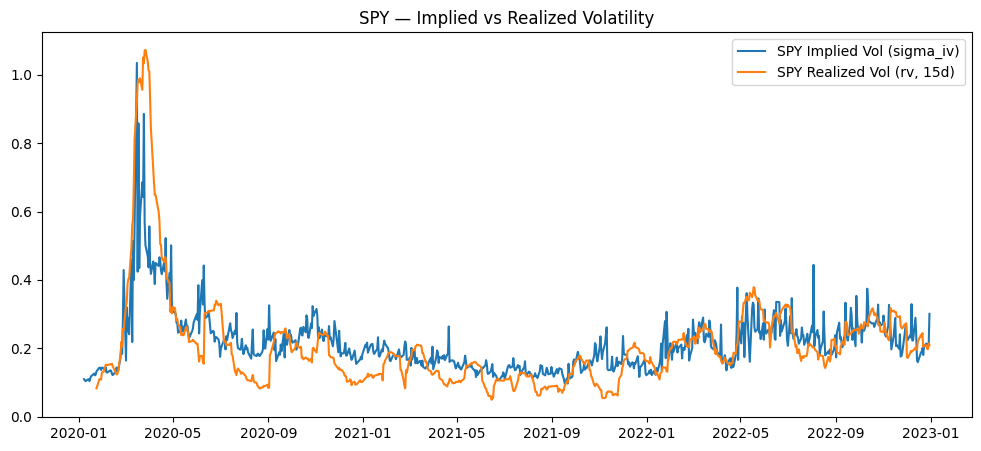

AAPL sigma_iv min/max: 0.16959666666666667 0.908531
AAPL rv       min/max: 0.12429703213943234 1.1702489608929025
SPY  sigma_iv min/max: 0.09673125 1.035125
SPY  rv       min/max: 0.04914219855766055 1.073507594346856


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1) Realized vol (annualisée)
# -----------------------------
def compute_realized_vol_clean(df_spot, window=15, ret_threshold=0.30):
    df = df_spot.copy()

    # 1) Identify abnormal returns
    abnormal = df["ret"].abs() > ret_threshold

    # 2) Replace abnormal returns by rolling median of previous 5 days
    rolling_med = df["ret"].rolling(5, min_periods=1).median()
    df.loc[abnormal, "ret"] = rolling_med[abnormal]

    # 3) Compute realized volatility
    df["rv"] = df["ret"].rolling(window).std() * np.sqrt(252)

    return df[["date", "rv"]]
    
rv_aapl = compute_realized_vol_clean(spot_data["AAPL"], window=15)
rv_spy  = compute_realized_vol_clean(spot_data["SPY"],  window=15)

# -----------------------------
# 2) Implied vol series
# -----------------------------
iv_aapl = iv_daily.loc[iv_daily["ticker"] == "AAPL", ["date", "sigma_iv"]].copy()
iv_spy  = iv_daily.loc[iv_daily["ticker"] == "SPY",  ["date", "sigma_iv"]].copy()

# Merge (align dates)
aapl_vol = iv_aapl.merge(rv_aapl, on="date", how="inner").sort_values("date")
spy_vol  = iv_spy.merge(rv_spy,   on="date", how="inner").sort_values("date")

# -----------------------------
# 3) Plot AAPL : IV + RV
# -----------------------------
plt.figure(figsize=(12,5))
plt.plot(aapl_vol["date"], aapl_vol["sigma_iv"], label="AAPL Implied Vol (sigma_iv)")
plt.plot(aapl_vol["date"], aapl_vol["rv"],       label="AAPL Realized Vol (rv, 15d)")
plt.title("AAPL — Implied vs Realized Volatility")
plt.legend()
plt.show()

# -----------------------------
# 4) Plot SPY : IV + RV
# -----------------------------
plt.figure(figsize=(12,5))
plt.plot(spy_vol["date"], spy_vol["sigma_iv"], label="SPY Implied Vol (sigma_iv)")
plt.plot(spy_vol["date"], spy_vol["rv"],       label="SPY Realized Vol (rv, 15d)")
plt.title("SPY — Implied vs Realized Volatility")
plt.legend()
plt.show()

# -----------------------------
# 5) Quick diagnostics (optional but useful)
# -----------------------------
print("AAPL sigma_iv min/max:", aapl_vol["sigma_iv"].min(), aapl_vol["sigma_iv"].max())
print("AAPL rv       min/max:", aapl_vol["rv"].min(), aapl_vol["rv"].max())
print("SPY  sigma_iv min/max:", spy_vol["sigma_iv"].min(), spy_vol["sigma_iv"].max())
print("SPY  rv       min/max:", spy_vol["rv"].min(), spy_vol["rv"].max())


### Data Cleaning for Realized Volatility

During the preliminary analysis, we detected extreme spikes in AAPL realized volatility (above 500% annualized), which are economically implausible even during the COVID-19 stress period.

These anomalies are caused by mechanical artifacts in the return series (e.g., corporate actions or imperfect price adjustments). Since realized volatility is computed as a rolling standard deviation, a single erroneous return can distort the entire window.

To ensure robustness while preserving continuity, we apply a return filter before computing realized volatility. Daily log-returns exceeding ±30% are treated as anomalies and replaced with a local rolling median estimate rather than removed.

This approach:
- Preserves time-series continuity  
- Prevents artificial volatility spikes  
- Maintains local statistical structure  

The cleaned realized volatility series is therefore economically consistent and suitable for IV–RV comparison.



## 4) UKF under Heston State-Space Model - Estimation de la volatilité latente et signal IV–σ̂

Cette section implémente un **Unscented Kalman Filter (UKF)** appliqué à un **modèle de Heston en espace d’état** afin d’estimer la variance latente \(v_t\) (donc \(\hat{\sigma}_t=\sqrt{v_t}\)) à partir des observations de marché.

### Données utilisées
On utilise les objets déjà construits :
- `spot_data[ticker]` avec les colonnes `["date","spot","logS","ret"]`
- `iv_daily` avec les colonnes `["date","ticker","sigma_iv"]` (proxy d’IV ATM)

### Étapes du pipeline
1. **Construction des observations (`build_df_obs`)**  
   On merge spot et implied vol au même pas de temps (daily), en nettoyant les types et les valeurs manquantes.

2. **Nettoyage des retours (`clean_returns_fill`)**  
   Les outliers de retours (ex. split/ajustements) sont remplacés par une moyenne locale *des jours précédents* pour conserver une série continue, puis on reconstruit `logS`.

3. **UKF — sigma points (`sigma_points`)**  
   Génération des sigma points (Julier–Uhlmann) avec une Cholesky robuste (`_chol_psd`) pour gérer les matrices quasi-singulières.

4. **Modèle d’état (Heston)**
   - **Transition** (Euler discretisé) sur l’état \(x_t = (\log S_t, v_t)\) via `heston_transition`
   - **Observation** via `measurement_fn` :  
     \[
     y_t = 
     \begin{pmatrix}
     \log S_t \\
     \sigma_{IV,t}
     \end{pmatrix}
     \approx
     \begin{pmatrix}
     \log S_t \\
     a + b\sqrt{v_t}
     \end{pmatrix}
     \]

5. **Filtrage UKF (`ukf_heston`)**
   Pour chaque date \(t\) :
   - **Predict** : propagation des sigma points via la transition
   - **Update** : correction avec l’observation \((\log S_t, \sigma_{IV,t})\)
   - Outputs principaux :  
     - \(\hat{v}_t\) (`v_hat`)  
     - \(\hat{\sigma}_t=\sqrt{\hat{v}_t}\) (`sigma_hat`)  
     - innovation sur l’IV (`innov_iv`)  
     - log-likelihood par pas (`ll`) utile pour calibration rolling

### Output
Le filtre renvoie un DataFrame contenant au minimum :
`["date","logS","sigma_iv","v_hat","sigma_hat","innov_iv","ll"]`

Ces séries serviront ensuite à construire le **spread** :
\[
s_t = \sigma_{IV,t} - \hat{\sigma}_t
\]
puis un **signal** (z-score / gating / sizing) pour le timing de la stratégie de carry.


In [25]:
# ============================================================
# UKF HESTON (SSM) + spread s_t = sigma_IV - sigma_hat + sizing
# Works with the objects we already built:
#   - spot_data["AAPL"] / spot_data["SPY"] with columns: ["date","spot","logS","ret"]
#   - iv_daily with columns: ["date","ticker","sigma_iv"] (and n_call_put if you kept it)
# ============================================================

import numpy as np
import pandas as pd

# -----------------------------
# 0) Build the observation df (logS + sigma_iv)
# -----------------------------
def build_df_obs(ticker: str, spot_data: dict, iv_daily: pd.DataFrame) -> pd.DataFrame:
    df_s = spot_data[ticker][["date", "logS", "ret"]].copy()
    df_i = iv_daily[iv_daily["ticker"] == ticker][["date", "sigma_iv"]].copy()

    df = df_s.merge(df_i, on="date", how="inner").sort_values("date").reset_index(drop=True)

    # Ensure clean dtypes
    df["date"] = pd.to_datetime(df["date"])
    for c in ["logS", "ret", "sigma_iv"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # Drop missing
    df = df.dropna(subset=["logS", "sigma_iv"]).reset_index(drop=True)
    return df


# -----------------------------
# 1) Clean AAPL returns (replace outliers by local rolling mean to keep continuity)
# -----------------------------
def clean_returns_fill(df_obs: pd.DataFrame, ret_col="ret", thresh=0.30, roll=5) -> pd.DataFrame:
    """
    Treat abs(ret)>thresh as data errors (e.g. split artifacts).
    Replace those returns by rolling mean of previous days (to keep continuity),
    then recompute logS cumulatively to stay consistent.
    """
    df = df_obs.copy().sort_values("date").reset_index(drop=True)

    # keep first logS anchor
    logS0 = float(df["logS"].iloc[0])

    # identify bad returns
    bad = df[ret_col].abs() > thresh
    # rolling mean of PREVIOUS days (shifted), so we don't leak the bad point into the mean
    repl = df[ret_col].rolling(roll, min_periods=1).mean().shift(1)
    # if early NaNs, fallback to 0
    repl = repl.fillna(0.0)

    # replace
    df.loc[bad, ret_col] = repl.loc[bad]

    # rebuild logS from cleaned returns (business-day increments)
    # Note: ret is log-return, so logS_t = logS0 + cumsum(ret) with logS[0]=logS0
    ret_filled = df[ret_col].fillna(0.0).to_numpy()
    logS_new = logS0 + np.r_[0.0, np.cumsum(ret_filled[1:])]
    df["logS"] = logS_new

    return df


# -----------------------------
# 2) UKF utilities (sigma points)
# -----------------------------
def _chol_psd(A, eps=1e-12):
    A = np.asarray(A, float)
    A = (A + A.T) / 2.0
    # jitter if needed
    jitter = 0.0
    for _ in range(8):
        try:
            return np.linalg.cholesky(A + (jitter + eps) * np.eye(A.shape[0]))
        except np.linalg.LinAlgError:
            jitter = max(10 * (jitter + eps), 1e-8)
    # last resort: eig clip
    w, V = np.linalg.eigh(A)
    w = np.clip(w, 1e-12, None)
    return np.linalg.cholesky(V @ np.diag(w) @ V.T)

def sigma_points(x, P, alpha=1e-3, beta=2.0, kappa=0.0):
    """
    Standard Julier–Uhlmann sigma points.
    x: (n,), P: (n,n)
    """
    x = np.asarray(x, float)
    P = np.asarray(P, float)
    n = x.size
    lam = alpha**2 * (n + kappa) - n
    S = _chol_psd((n + lam) * P)

    Xi = np.zeros((2 * n + 1, n))
    Xi[0] = x
    for i in range(n):
        Xi[i + 1]     = x + S[:, i]
        Xi[n + i + 1] = x - S[:, i]

    Wm = np.full(2 * n + 1, 1.0 / (2.0 * (n + lam)))
    Wc = np.full(2 * n + 1, 1.0 / (2.0 * (n + lam)))
    Wm[0] = lam / (n + lam)
    Wc[0] = lam / (n + lam) + (1.0 - alpha**2 + beta)
    return Xi, Wm, Wc


# -----------------------------
# 3) Heston SSM (process + measurement)
# -----------------------------
def heston_transition(x, dt, mu, kappa, theta, xi):
    """
    Deterministic part of Euler transition (noise handled via Q in UKF).
    State x = [logS, v]
    """
    logS, v = float(x[0]), float(x[1])
    v = max(v, 1e-10)

    logS_next = logS + (mu - 0.5 * v) * dt
    v_next    = v + kappa * (theta - v) * dt

    # keep v positive
    v_next = max(v_next, 1e-10)
    return np.array([logS_next, v_next], float)

def measurement_fn(x, a=0.0, b=1.0):
    """
    Observe y = [logS, sigma_iv]
    sigma_iv approx = a + b*sqrt(v)
    """
    logS, v = float(x[0]), float(x[1])
    v = max(v, 1e-10)
    return np.array([logS, a + b * np.sqrt(v)], float)


# -----------------------------
# 4) UKF filter main
# -----------------------------
def ukf_heston(
    df_obs: pd.DataFrame,
    *,
    dt=1/252,
    mu=0.0,
    kappa=5.0,
    theta=0.10,     # variance level (sigma ~ 31%)
    xi=0.50,
    a_iv=0.0, b_iv=1.0,
    # process / measurement noise (tuneable)
    q_logS=1e-6,
    q_v=1e-4,
    r_logS=1e-6,
    r_iv=1e-3,
    # UKF hyperparams
    alpha=1e-3, beta=2.0, kappa_sp=0.0,
):
    """
    Returns df with columns: date, logS, sigma_iv, v_hat, sigma_hat, innov_iv, ll
    """
    df = df_obs.copy().sort_values("date").reset_index(drop=True)

    y_logS = df["logS"].to_numpy()
    y_iv   = df["sigma_iv"].to_numpy()

    # init: logS from first obs, v from iv^2 (rough)
    x = np.array([y_logS[0], max(y_iv[0]**2, 1e-6)], float)
    P = np.diag([1e-4, 1e-2])  # fairly loose init

    Q = np.diag([q_logS, q_v])
    R = np.diag([r_logS, r_iv])

    v_hat = np.zeros(len(df))
    s_hat = np.zeros(len(df))
    innov_iv = np.zeros(len(df))
    ll = np.zeros(len(df))

    for t in range(len(df)):
        # ---- Predict
        Xi, Wm, Wc = sigma_points(x, P, alpha=alpha, beta=beta, kappa=kappa_sp)
        # propagate
        Xpred = np.array([heston_transition(Xi[i], dt, mu, kappa, theta, xi) for i in range(Xi.shape[0])])
        x_pred = (Wm[:, None] * Xpred).sum(axis=0)
        P_pred = Q.copy()
        for i in range(Xpred.shape[0]):
            dx = (Xpred[i] - x_pred).reshape(-1, 1)
            P_pred += Wc[i] * (dx @ dx.T)

        # ---- Update with y = [logS, sigma_iv]
        Yi = np.array([measurement_fn(Xpred[i], a=a_iv, b=b_iv) for i in range(Xpred.shape[0])])
        y_pred = (Wm[:, None] * Yi).sum(axis=0)

        S = R.copy()
        C = np.zeros((2, 2))
        for i in range(Yi.shape[0]):
            dy = (Yi[i] - y_pred).reshape(-1, 1)
            dx = (Xpred[i] - x_pred).reshape(-1, 1)
            S += Wc[i] * (dy @ dy.T)
            C += Wc[i] * (dx @ dy.T)

        # innovation
        y = np.array([y_logS[t], y_iv[t]], float)
        e = (y - y_pred)

        # Kalman gain
        Sinv = np.linalg.inv(S)
        K = C @ Sinv

        # posterior
        x = x_pred + K @ e
        P = P_pred - K @ S @ K.T
        P = (P + P.T) / 2.0

        # store
        v = max(float(x[1]), 1e-10)
        v_hat[t] = v
        s_hat[t] = np.sqrt(v)
        innov_iv[t] = e[1]

        # Gaussian log-likelihood contribution (optional, useful for rolling calib)
        # ll_t = -0.5*(log|S| + e'S^-1 e + d log(2pi))
        d = 2
        sign, logdet = np.linalg.slogdet(S)
        if sign <= 0:
            logdet = np.log(max(np.linalg.det(S), 1e-18))
        ll[t] = -0.5 * (logdet + e.T @ Sinv @ e + d * np.log(2*np.pi))

    out = df.copy()
    out["v_hat"] = v_hat
    out["sigma_hat"] = s_hat
    out["innov_iv"] = innov_iv
    out["ll"] = ll
    return out




## Construction du signal IV–σ̂ et allocation dynamique

À partir de la volatilité implicite observée \( \sigma_{IV,t} \) et de la volatilité estimée par UKF \( \hat{\sigma}_t \), on construit un **signal de spread** :

\[
\text{spread}_t = \sigma_{IV,t} - \hat{\sigma}_t
\]

L’idée économique est simple :
- Si IV > volatilité estimée → la volatilité implicite est “chère” → opportunité de short vol.
- Si IV ≈ σ̂ → pas d’avantage clair → pas d’exposition.

---

### 1️⃣ Normalisation : z-score rolling

On calcule un z-score du spread sur une fenêtre glissante :

\[
z_t = \frac{\text{spread}_t - \mu_t}{\sigma_t}
\]

avec moyenne et écart-type calculés sur `z_window` jours.

Le z-score est ensuite borné (`z_clip`) pour éviter les valeurs extrêmes instables.

---

### 2️⃣ Filtrage robuste du signal

Le poids dynamique \( w_t \) combine trois mécanismes de robustesse :

- **Gate d’entrée** :  
  Position ouverte uniquement si \( z_t > z_{entry} \)

- **Volatility cap** :  
  Pas de short si \( \hat{\sigma}_t \) dépasse `vol_cap` (régime de stress)

- **Risk targeting** :  
  \[
  \text{risk\_scale}_t = \frac{\text{target\_vol}}{\hat{\sigma}_t}
  \]
  pour adapter la taille de position au régime de volatilité.

Le poids final est :

\[
w_t = \text{gate}_t \times \text{safe}_t \times \text{risk\_scale}_t
\]

avec bornes \( [0, w_{max}] \).

---

### 3️⃣ Pipeline complet

Pour chaque ticker (AAPL, SPY) :

1. Construction des observations
2. Nettoyage des retours
3. Estimation UKF (volatilité latente)
4. Construction du spread
5. Génération du poids dynamique
6. Visualisation :
   - IV vs σ̂
   - z-score du spread
   - poids dynamique

---

### Interprétation économique

Le modèle cherche à exploiter un **volatility risk premium conditionnel** :

- Short vol uniquement lorsque IV est significativement au-dessus de la vol attendue.
- Réduction de l’exposition en régime de volatilité élevée.
- Adaptation automatique du levier via risk targeting.

Cela transforme une stratégie short straddle “statique” en stratégie **timée et risk-managed**.


,date,logS,ret,sigma_iv,v_hat,sigma_hat,innov_iv,ll,spread,spread_z,w
0,2020-01-08,5.714360,0.015958,0.289450,0.106862,0.326897,0.047747,4.400243,-0.037447,NaN,0.0
1,2020-01-09,5.735378,0.021018,0.312445,0.095888,0.309657,-0.006737,-57.601089,0.002788,NaN,0.0
2,2020-01-10,5.737636,0.002258,0.325205,0.100499,0.317016,0.019453,-4.238464,0.008189,NaN,0.0
3,2020-01-13,5.758776,0.021139,0.339285,0.101605,0.318755,0.025315,-83.217027,0.020530,NaN,0.0
4,2020-01-14,5.745180,-0.013595,0.350455,0.115321,0.339589,0.034629,1.731682,0.010866,NaN,0.0


AAPL sigma_iv min/max: 0.16959666666666667 0.908531
AAPL sigma_hat min/max: 0.18890329739367961 0.8381034319850237
AAPL spread_z stats: count    796.000000
mean       0.015463
std        0.959984
min       -3.000000
5%        -1.355102
50%       -0.108605
95%        1.886395
max        3.000000
Name: spread_z, dtype: float64


,date,logS,ret,sigma_iv,v_hat,sigma_hat,innov_iv,ll,spread,spread_z,w
0,2020-01-08,5.781946,0.005099,0.109455,0.034380,0.185419,0.871997,2.266694,-0.075964,NaN,0.0
1,2020-01-09,5.788706,0.006759,0.106160,0.034865,0.186721,0.088640,-1.247512,-0.080561,NaN,0.0
2,2020-01-10,5.785792,-0.002913,0.103625,0.035739,0.189048,-0.000933,5.897862,-0.085423,NaN,0.0
3,2020-01-13,5.792770,0.006977,0.108585,0.019365,0.139158,-0.049519,-0.616931,-0.030573,NaN,0.0
4,2020-01-14,5.791244,-0.001526,0.109185,0.019686,0.140308,0.000513,6.604959,-0.031123,NaN,0.0


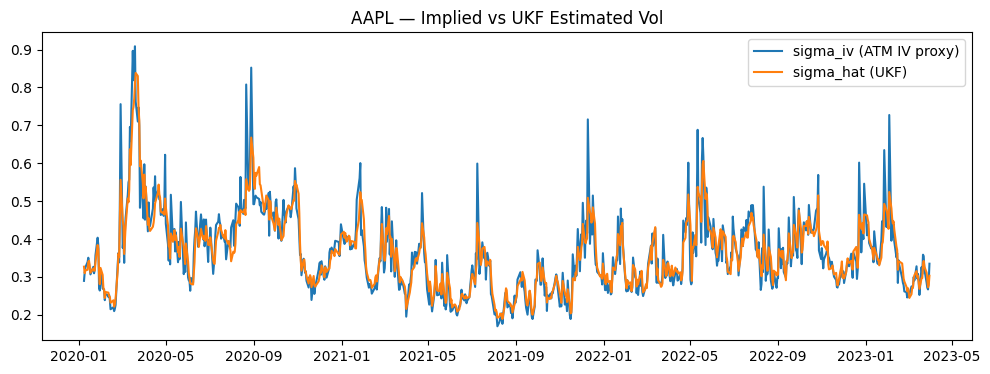

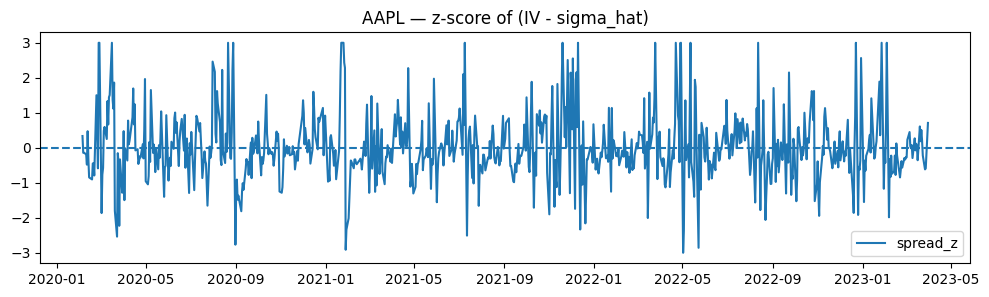

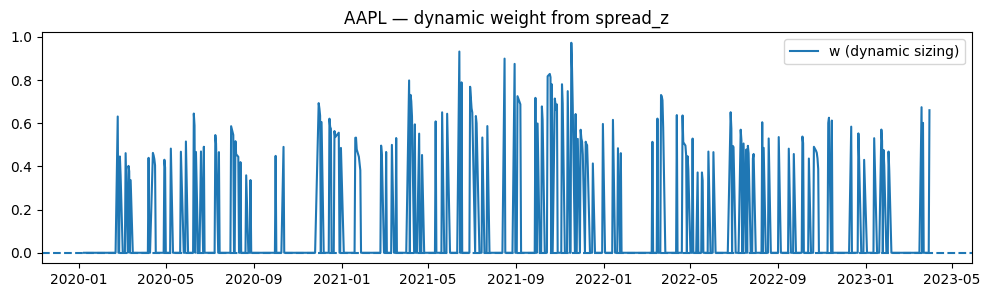

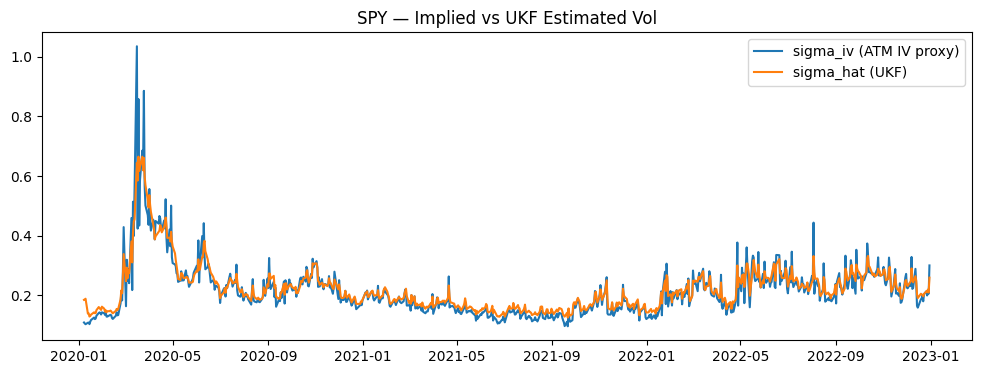

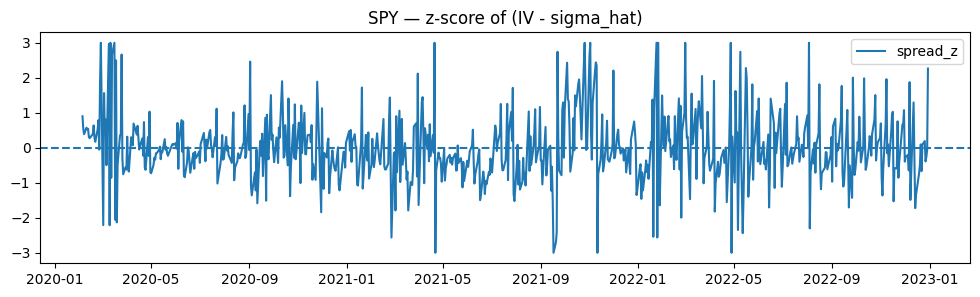

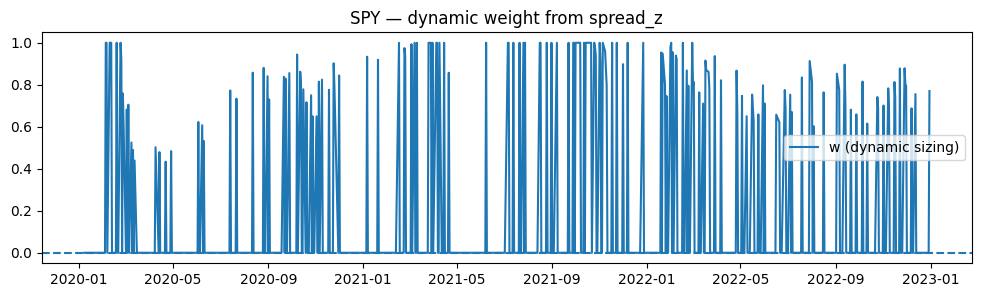

In [ ]:
# -----------------------------
# 5) Build spread + zscore + weight (dynamic allocation signal)
# -----------------------------
# def add_spread_and_sizing_asymmetric(df_filt, z_window=63, w_max=1.0):
#     df = df_filt.copy().sort_values("date").reset_index(drop=True)

#     df["spread"] = df["sigma_iv"] - df["sigma_hat"]

#     m = df["spread"].rolling(z_window, min_periods=20).mean()
#     s = df["spread"].rolling(z_window, min_periods=20).std()

#     df["spread_z"] = (df["spread"] - m) / s

#     # ASYMMETRIC: short only when spread positive
#     df["w"] = df["spread_z"].clip(lower=0.0)  # no negative exposure
#     df["w"] = (df["w"] / 3.0).clip(0.0, w_max)

#     return df

def add_spread_and_sizing_robust(
    df_filt: pd.DataFrame,
    z_window=63,
    z_entry=0.5,
    vol_cap=0.60,
    target_vol=0.20,
    w_max=1.0,
    z_clip=3.0,
):
    df = df_filt.copy().sort_values("date").reset_index(drop=True)

    df["spread"] = df["sigma_iv"] - df["sigma_hat"]

    m = df["spread"].rolling(z_window, min_periods=20).mean()
    s = df["spread"].rolling(z_window, min_periods=20).std()

    df["spread_z"] = ((df["spread"] - m) / s).clip(-z_clip, z_clip)

    # Gate
    gate = (df["spread_z"] > z_entry).astype(float)

    # Vol cap (avoid shorting when vol extreme)
    safe = (df["sigma_hat"] < vol_cap).astype(float)

    # Risk targeting
    risk_scale = (target_vol / df["sigma_hat"]).clip(0.0, w_max)

    df["w"] = (gate * safe * risk_scale).fillna(0.0)

    return df


# ============================================================
# RUN (AAPL)
# ============================================================
ticker = "AAPL"

df_obs = build_df_obs(ticker, spot_data, iv_daily)
df_obs = clean_returns_fill(df_obs, thresh=0.30, roll=5)  # continuity-friendly cleaning

# UKF (starting params — you can tune later or do rolling MLE)
df_ukf = ukf_heston(
    df_obs,
    mu=0.00,
    kappa=5.0,
    theta=(df_obs["sigma_iv"].median()**2),  # decent anchor
    xi=0.60,
    a_iv=0.0, b_iv=1.0,
    q_logS=1e-6, q_v=5e-4,
    r_logS=1e-6, r_iv=2e-3,
)

# df_sig = add_spread_and_sizing_asymmetric(df_ukf, z_window=63, w_max=1.0)
df_sig = add_spread_and_sizing_robust(
    df_ukf,
    z_window=63,
    z_entry=0.5,
    vol_cap=0.60,
    target_vol=0.20
)

display(df_sig.head())
print("AAPL sigma_iv min/max:", df_sig["sigma_iv"].min(), df_sig["sigma_iv"].max())
print("AAPL sigma_hat min/max:", df_sig["sigma_hat"].min(), df_sig["sigma_hat"].max())
print("AAPL spread_z stats:", df_sig["spread_z"].describe(percentiles=[0.05,0.5,0.95]))


# ============================================================
# RUN (SPY) — same pipeline, no special cleaning needed usually
# ============================================================
ticker = "SPY"

df_obs_spy = build_df_obs(ticker, spot_data, iv_daily)
df_ukf_spy = ukf_heston(
    df_obs_spy,
    mu=0.00,
    kappa=4.0,
    theta=(df_obs_spy["sigma_iv"].median()**2),
    xi=0.50,
    a_iv=0.0, b_iv=1.0,
    q_logS=1e-6, q_v=3e-4,
    r_logS=1e-6, r_iv=2e-3,
)
# df_sig_spy = add_spread_and_sizing_asymmetric(df_ukf_spy, z_window=63, w_max=1.0)
df_sig_spy = add_spread_and_sizing_robust(
    df_ukf_spy,
    z_window=63,
    z_entry=0.5,
    vol_cap=0.60,
    target_vol=0.20
)

display(df_sig_spy.head())


# ============================================================
# QUICK PLOTS (IV vs sigma_hat + spread_z + weights)
# ============================================================
import matplotlib.pyplot as plt

def plot_ukf_outputs(df_sig, title_prefix=""):
    plt.figure(figsize=(12,4))
    plt.plot(df_sig["date"], df_sig["sigma_iv"], label="sigma_iv (ATM IV proxy)")
    plt.plot(df_sig["date"], df_sig["sigma_hat"], label="sigma_hat (UKF)")
    plt.title(f"{title_prefix} Implied vs UKF Estimated Vol")
    plt.legend()
    plt.show()

    plt.figure(figsize=(12,3))
    plt.plot(df_sig["date"], df_sig["spread_z"], label="spread_z")
    plt.axhline(0, linestyle="--")
    plt.title(f"{title_prefix} z-score of (IV - sigma_hat)")
    plt.legend()
    plt.show()

    plt.figure(figsize=(12,3))
    plt.plot(df_sig["date"], df_sig["w"], label="w (dynamic sizing)")
    plt.axhline(0, linestyle="--")
    plt.title(f"{title_prefix} dynamic weight from spread_z")
    plt.legend()
    plt.show()

plot_ukf_outputs(df_sig, "AAPL —")
plot_ukf_outputs(df_sig_spy, "SPY —")



## Backtest proxy et métriques de performance

### 1️⃣ Fonction de statistiques de performance

La fonction `perf_stats` calcule les métriques standards :

- **Rendement annualisé**
\[
R_{ann} = \text{NAV}_T^{\frac{252}{N}} - 1
\]

- **Volatilité annualisée**
\[
\sigma_{ann} = \sigma_{daily} \times \sqrt{252}
\]

- **Sharpe ratio**
\[
\text{Sharpe} = \frac{R_{ann}}{\sigma_{ann}}
\]

- **Max Drawdown**
\[
\text{MDD} = \min\left(\frac{NAV_t}{\max_{s \le t} NAV_s} - 1\right)
\]

Cela permet de comparer proprement :
- stratégie baseline (exposition constante),
- stratégie dynamique (timing UKF).

---

### 2️⃣ Proxy PnL

On construit un proxy simple du payoff short volatility :

\[
\text{edge}_t = \sigma_{IV,t} - \hat{\sigma}_t
\]

Hypothèse économique :

- Si IV > vol estimée → prime de volatilité positive → short vol gagne
- Si IV < vol estimée → short vol perd

La baseline correspond à une exposition constante (=1).

---

### 3️⃣ Construction du backtest (sans look-ahead)

On fusionne :
- le signal \( w_t \)
- le proxy de rendement

Puis on applique :

\[
w_{used,t} = w_{t-1}
\]

afin d’éviter tout biais d’anticipation.

C’est crucial :  
le signal du jour t ne peut être utilisé que le jour t+1.

---

### 4️⃣ Comparaison baseline vs flipped

On teste :

- `baseline` : short vol
- `baseline_flipped` : long vol

Cela permet de vérifier si le proxy est bien orienté et si le volatility risk premium est présent dans les données.

---

### ⚠️ Important

Ce backtest reste un **proxy théorique** :

- Pas de greeks
- Pas de gamma bleed
- Pas de transaction costs
- Pas de smile / skew
- Pas de path dependency

Il sert uniquement à tester :
> "Est-ce que le timing du spread IV – σ̂ apporte de l'information directionnelle ?"

Le vrai test nécessitera :
- pricing réel de straddles,
- delta-hedging dynamique,
- gestion des greeks.

---

### Interprétation attendue

Si le modèle fonctionne :

- baseline ≈ faible Sharpe (VRP moyen)
- dynamic → meilleure Sharpe
- drawdown réduit
- volatilité plus stable

Sinon :
- le signal n’apporte pas d’information exploitable
- ou le proxy est trop simplifié


In [28]:
def perf_stats(ret, ann=252):
    ret = pd.Series(ret).dropna()
    nav = (1 + ret).cumprod()
    ann_ret = nav.iloc[-1] ** (ann/len(ret)) - 1
    ann_vol = ret.std() * np.sqrt(ann)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
    dd = nav / nav.cummax() - 1
    return {"n": len(ret), "ann_ret": float(ann_ret),
            "ann_vol": float(ann_vol),
            "sharpe": float(sharpe),
            "max_dd": float(dd.min())}

# Simple proxy PnL: short vol earns when RV < IV
df_strat_ret = df_sig[["date","sigma_iv","sigma_hat"]].copy()
df_strat_ret["strat_ret"] = df_strat_ret["sigma_iv"] - df_strat_ret["sigma_hat"]

# ------------------------------------------------------------
# Build backtest dataframe
# ------------------------------------------------------------
df_bt = (
    df_sig[["date","w"]]
    .merge(df_strat_ret[["date","strat_ret"]], on="date", how="inner")
    .sort_values("date")
    .reset_index(drop=True)
)

# Use yesterday's signal (avoid look-ahead bias)
df_bt["w_used"] = df_bt["w"].shift(1).fillna(0.0)

df_bt.head()


print("baseline:", perf_stats(df_bt["strat_ret"]))
print("baseline_flipped:", perf_stats(-df_bt["strat_ret"]))


baseline: {'n': 815, 'ann_ret': -0.08526479042852053, 'ann_vol': 0.5909187896433229, 'sharpe': -0.1442918924273607, 'max_dd': -0.8724301771046696}
baseline_flipped: {'n': 815, 'ann_ret': -0.2307560439034968, 'ann_vol': 0.5909187896433229, 'sharpe': -0.3905038187104874, 'max_dd': -0.891768909770042}


AAPL baseline: {'n': 815, 'ann_ret': -0.08526479042852053, 'ann_vol': 0.5909187896433229, 'sharpe': -0.1442918924273607, 'max_dd': -0.8724301771046696}
AAPL dynamic : {'n': 815, 'ann_ret': 0.03620361461803645, 'ann_vol': 0.06326305401127022, 'sharpe': 0.5722710543121555, 'max_dd': -0.10536290670566617}
SPY baseline : {'n': 754, 'ann_ret': -0.843626229153041, 'ann_vol': 0.4659079574261912, 'sharpe': -1.810714360436069, 'max_dd': -0.9959657090958499}
SPY dynamic  : {'n': 754, 'ann_ret': -0.12116734895113723, 'ann_vol': 0.0744723320893103, 'sharpe': -1.6270116102424232, 'max_dd': -0.3830041650312975}


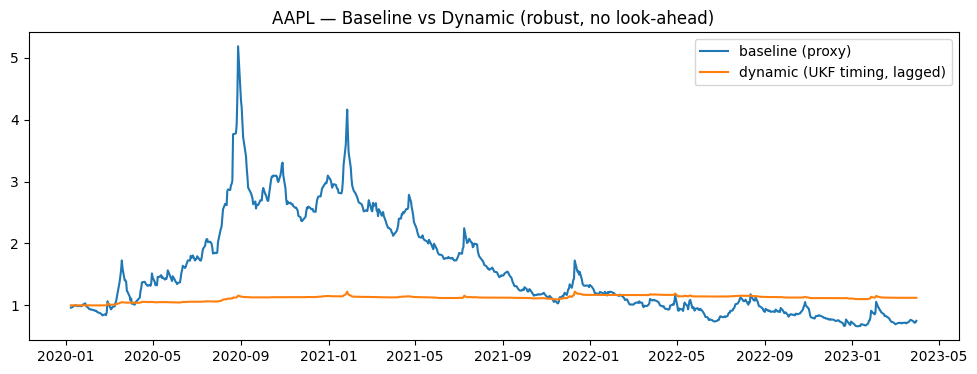

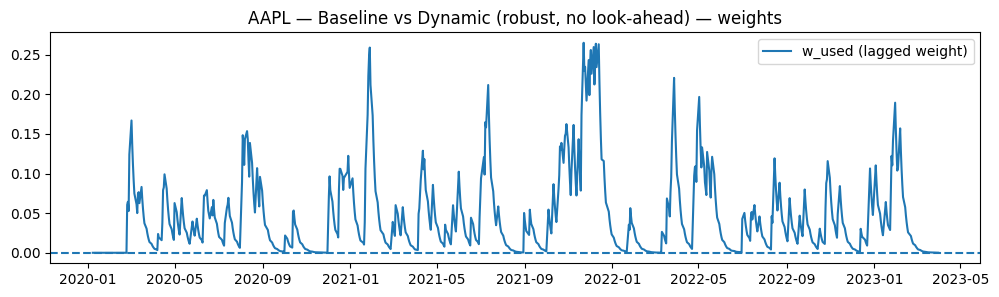

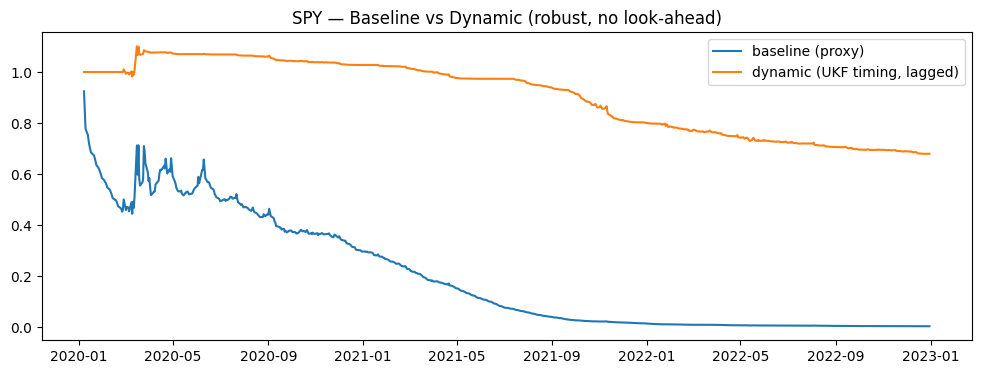

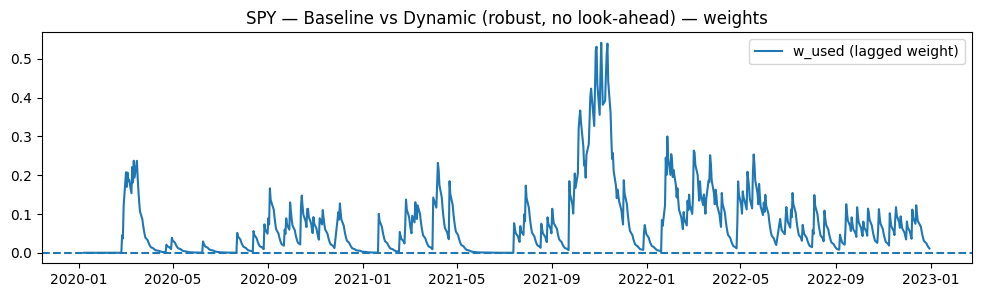

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Robust signal builder (NO LOOK-AHEAD)
# ------------------------------------------------------------
def build_signal_robust(
    df_sig: pd.DataFrame,
    *,
    z_window=63,
    z_entry=0.75,       # entry threshold
    z_exit=0.25,        # exit threshold (hysteresis)
    z_clip=3.0,
    vol_cap=0.60,       # don't short if sigma_hat too high
    target_vol=0.20,    # risk target on sigma_hat
    w_max=1.0,
    smooth_span=10,     # EWMA smoothing on w
    short_only=True     # keep it asymmetric: short only when spread suggests
) -> pd.DataFrame:
    df = df_sig.copy().sort_values("date").reset_index(drop=True)

    # spread (level)
    df["spread"] = df["sigma_iv"] - df["sigma_hat"]

    # rolling stats built on past only -> shift(1)
    mu = df["spread"].rolling(z_window, min_periods=max(20, z_window//3)).mean().shift(1)
    sd = df["spread"].rolling(z_window, min_periods=max(20, z_window//3)).std().shift(1)

    df["spread_z"] = ((df["spread"] - mu) / sd).replace([np.inf, -np.inf], np.nan)
    df["spread_z"] = df["spread_z"].clip(-z_clip, z_clip)

    # -------------------------
    # Entry/Exit hysteresis (stateful position)
    # -------------------------
    pos = np.zeros(len(df), dtype=float)
    in_pos = False

    for i in range(len(df)):
        z = df["spread_z"].iloc[i]
        sh = df["sigma_hat"].iloc[i]

        if np.isnan(z) or np.isnan(sh):
            pos[i] = 0.0
            in_pos = False
            continue

        # hard risk stop: if vol too high -> no position
        if sh >= vol_cap:
            pos[i] = 0.0
            in_pos = False
            continue

        if not in_pos:
            if z > z_entry:
                in_pos = True
        else:
            if z < z_exit:
                in_pos = False

        pos[i] = 1.0 if in_pos else 0.0

    df["gate"] = pos

    # -------------------------
    # Risk targeting (smoothed)
    # -------------------------
    risk_scale = (target_vol / df["sigma_hat"]).clip(0.0, w_max)

    # Raw weight: proportional to positive z (asymmetric)
    z_pos = df["spread_z"].clip(lower=0.0) if short_only else df["spread_z"]
    w_raw = df["gate"] * (z_pos / z_clip).clip(0.0, 1.0) * risk_scale

    # Smooth to avoid “barcode” positions
    df["w"] = pd.Series(w_raw).ewm(span=smooth_span, adjust=False).mean().clip(0.0, w_max)

    # IMPORTANT: for trading, use yesterday's weight
    df["w_used"] = df["w"].shift(1).fillna(0.0)

    return df


# ------------------------------------------------------------
# Proxy backtest (consistent, still a proxy)
# ------------------------------------------------------------
def perf_stats(ret, ann=252):
    ret = pd.Series(ret).dropna()
    nav = (1 + ret).cumprod()
    ann_ret = nav.iloc[-1] ** (ann/len(ret)) - 1
    ann_vol = ret.std() * np.sqrt(ann)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
    dd = nav / nav.cummax() - 1
    return {"n": len(ret), "ann_ret": float(ann_ret),
            "ann_vol": float(ann_vol),
            "sharpe": float(sharpe),
            "max_dd": float(dd.min())}


def run_proxy_bt(df_signal: pd.DataFrame) -> pd.DataFrame:
    """
    Proxy payoff: proportional to (IV - expected vol).
    Baseline assumes constant short exposure (=1).
    Dynamic uses w_used (lagged, no look-ahead).
    """
    df = df_signal.copy().sort_values("date").reset_index(drop=True)

    # proxy "edge"
    df["edge"] = df["sigma_iv"] - df["sigma_hat"]

    # baseline: constant exposure (short vol)
    df["ret_baseline"] = df["edge"]

    # dynamic: lagged weight (no look-ahead)
    df["ret_dynamic"]  = df["w_used"] * df["edge"]

    # NAVs
    df["nav_baseline"] = (1 + df["ret_baseline"]).cumprod()
    df["nav_dynamic"]  = (1 + df["ret_dynamic"]).cumprod()

    return df


# ============================================================
# APPLY TO AAPL + SPY
# (Assumes you already have df_sig and df_sig_spy produced by your UKF block)
# ============================================================

df_sig2     = build_signal_robust(df_sig, z_window=63, z_entry=0.75, z_exit=0.25,
                                  vol_cap=0.60, target_vol=0.20, smooth_span=10, w_max=1.0)

df_sig2_spy = build_signal_robust(df_sig_spy, z_window=63, z_entry=0.75, z_exit=0.25,
                                  vol_cap=0.60, target_vol=0.20, smooth_span=10, w_max=1.0)

df_bt_aapl = run_proxy_bt(df_sig2)
df_bt_spy  = run_proxy_bt(df_sig2_spy)

print("AAPL baseline:", perf_stats(df_bt_aapl["ret_baseline"]))
print("AAPL dynamic :", perf_stats(df_bt_aapl["ret_dynamic"]))
print("SPY baseline :", perf_stats(df_bt_spy["ret_baseline"]))
print("SPY dynamic  :", perf_stats(df_bt_spy["ret_dynamic"]))

# Plots
def plot_bt(df_bt, title):
    plt.figure(figsize=(12,4))
    plt.plot(df_bt["date"], df_bt["nav_baseline"], label="baseline (proxy)")
    plt.plot(df_bt["date"], df_bt["nav_dynamic"],  label="dynamic (UKF timing, lagged)")
    plt.title(title)
    plt.legend()
    plt.show()

    plt.figure(figsize=(12,3))
    plt.plot(df_bt["date"], df_bt["w_used"], label="w_used (lagged weight)")
    plt.axhline(0, linestyle="--")
    plt.title(title + " — weights")
    plt.legend()
    plt.show()

plot_bt(df_bt_aapl, "AAPL — Baseline vs Dynamic (robust, no look-ahead)")
plot_bt(df_bt_spy,  "SPY — Baseline vs Dynamic (robust, no look-ahead)")


AAPL baseline: {'n': 815, 'ann_ret': 0.0634622183287219, 'ann_vol': 0.6293534701157386, 'sharpe': 0.10083716280622262, 'max_dd': -0.37098794230325827}
AAPL dynamic : {'n': 815, 'ann_ret': -0.15980462354169445, 'ann_vol': 0.17512339662719253, 'sharpe': -0.9125258338946617, 'max_dd': -0.5353961107011731}


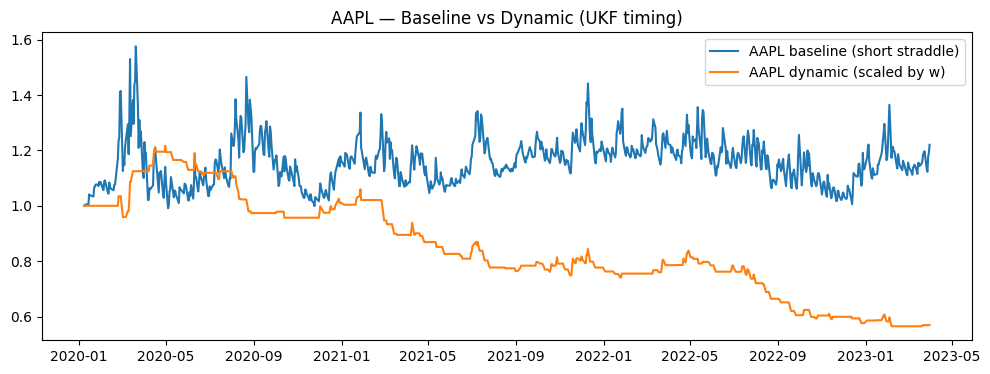

SPY baseline: {'n': 754, 'ann_ret': -0.012032738837132961, 'ann_vol': 0.3981199267009926, 'sharpe': -0.030223904984716155, 'max_dd': -0.4115129005759046}
SPY dynamic : {'n': 754, 'ann_ret': -0.13305432102818726, 'ann_vol': 0.1471826127765688, 'sharpe': -0.9040084186450131, 'max_dd': -0.44355727322011507}


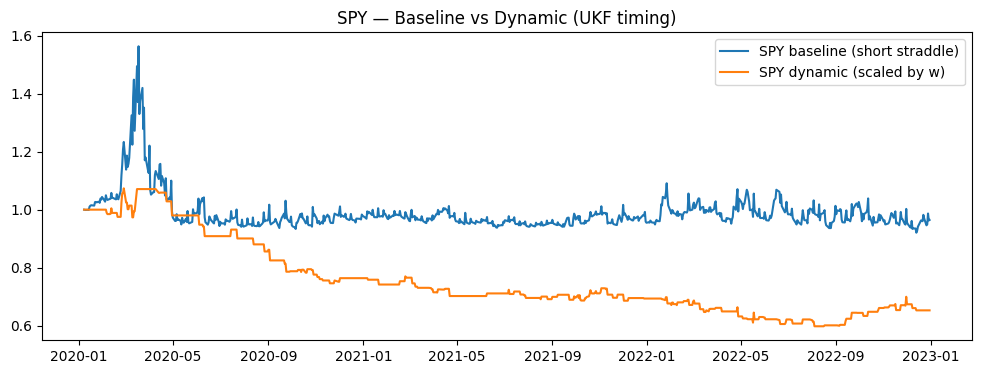

AAPL % days full straddle (2 legs): 1.0
SPY  % days full straddle (2 legs): 1.0


In [30]:
# ============================================================
# NEXT STEP: Backtest the carry strategy (short straddle)
# Baseline: always short straddle (exposure = 1)
# Dynamic : exposure scaled by w_t (from spread_z), with NO look-ahead (shift(1))
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from investment_lab.option_trade import OptionTrade
from investment_lab.option_strategies import SHORT_1M_STRADDLE  # or SHORT_1W_STRADDLE if you prefer

# -----------------------------
# 1) Build daily strategy value from OptionTrade trades (mid prices)
# -----------------------------
def build_daily_straddle_value(
    start_date, end_date, ticker: str, legs=SHORT_1M_STRADDLE, cost_neutral=False
) -> pd.DataFrame:
    """
    Uses OptionTrade._generate_trades() which returns a DAILY panel with option greeks, mid, etc.
    We compute a daily strategy 'value' = sum(weight * mid) across legs.
    Then daily return = -pct_change(value) or pct_change(value) depending on sign convention.
    
    Note: For a short straddle, the mark-to-market value is typically negative (short premium),
    so we define PnL using changes in value rather than pct_change on a negative series.
    """
    df_tr = OptionTrade._generate_trades(
        start_date=start_date,
        end_date=end_date,
        tickers=[ticker],
        legs=legs,
        cost_neutral=cost_neutral
    ).copy()

    # sanity checks
    req = {"date", "ticker", "leg_name", "weight", "mid"}
    missing = req - set(df_tr.columns)
    if missing:
        raise KeyError(f"Missing columns in df_trades_daily: {missing}. Available: {df_tr.columns.tolist()}")

    df_tr["date"] = pd.to_datetime(df_tr["date"])
    df_tr = df_tr.sort_values(["date", "leg_name"]).reset_index(drop=True)

    # daily strategy mark-to-market value (in $ units, since weight ~ shares notion)
    df_val = (
        df_tr.groupby("date", as_index=False)
             .apply(lambda x: pd.Series({
                 "value": float((x["weight"] * x["mid"]).sum()),
                 "n_legs": int(x["leg_name"].nunique()),
             }))
             .reset_index(drop=True)
    )

    # daily PnL = -(value_t - value_{t-1}) if you are SHORT the options (depends on how weights are signed)
    # Here weights in SHORT_1M_STRADDLE are negative, so value is usually negative.
    # The cleanest is: pnl = -(value - value.shift(1))  (so that increasing option prices => losses)
    df_val["pnl"] = -(df_val["value"] - df_val["value"].shift(1))
    df_val["pnl"] = df_val["pnl"].fillna(0.0)

    # turn into returns by scaling with a proxy capital (to avoid dividing by near-zero / negative value)
    # Choose a stable capital base (e.g., 1.0) and interpret returns as "PnL per unit capital".
    # If you want more realism: set capital = abs(value).rolling(...).mean() etc.
    capital = 1.0
    df_val["ret"] = df_val["pnl"] / capital

    return df_val[["date", "value", "pnl", "ret", "n_legs"]].sort_values("date")


# -----------------------------
# 2) Merge with signal w_t and build baseline vs dynamic NAV
# -----------------------------
def backtest_with_signal(df_strat: pd.DataFrame, df_sig: pd.DataFrame, w_col="w") -> pd.DataFrame:
    df = df_strat.merge(df_sig[["date", w_col]], on="date", how="inner").sort_values("date").reset_index(drop=True)

    # NO look-ahead: use yesterday's signal to scale today's strategy return
    df["w_lag"] = df[w_col].shift(1).fillna(0.0)

    df["ret_baseline"] = df["ret"]
    df["ret_dynamic"]  = df["w_lag"] * df["ret"]

    df["nav_baseline"] = (1.0 + df["ret_baseline"]).cumprod()
    df["nav_dynamic"]  = (1.0 + df["ret_dynamic"]).cumprod()

    return df


# -----------------------------
# 3) Simple perf metrics
# -----------------------------
def perf_stats(ret: pd.Series, ann=252):
    r = ret.dropna()
    if len(r) < 10:
        return {"n": len(r), "ann_ret": np.nan, "ann_vol": np.nan, "sharpe": np.nan, "max_dd": np.nan}

    nav = (1 + r).cumprod()
    dd = nav / nav.cummax() - 1.0

    ann_ret = nav.iloc[-1] ** (ann / len(r)) - 1
    ann_vol = r.std() * np.sqrt(ann)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
    max_dd  = dd.min()

    return {"n": len(r), "ann_ret": float(ann_ret), "ann_vol": float(ann_vol), "sharpe": float(sharpe), "max_dd": float(max_dd)}


# ============================================================
# RUN for AAPL
# ============================================================
START_DATE = pd.to_datetime("2020-01-02")
END_DATE   = pd.to_datetime("2023-12-29")

# df_sig already computed by your UKF pipeline for AAPL (must contain 'date' and 'w')
df_strat_aapl = build_daily_straddle_value(START_DATE, END_DATE, "AAPL", legs=SHORT_1M_STRADDLE)
bt_aapl = backtest_with_signal(df_strat_aapl, df_sig, w_col="w")

print("AAPL baseline:", perf_stats(bt_aapl["ret_baseline"]))
print("AAPL dynamic :", perf_stats(bt_aapl["ret_dynamic"]))

plt.figure(figsize=(12,4))
plt.plot(bt_aapl["date"], bt_aapl["nav_baseline"], label="AAPL baseline (short straddle)")
plt.plot(bt_aapl["date"], bt_aapl["nav_dynamic"],  label="AAPL dynamic (scaled by w)")
plt.title("AAPL — Baseline vs Dynamic (UKF timing)")
plt.legend()
plt.show()


# ============================================================
# RUN for SPY
# ============================================================
df_strat_spy = build_daily_straddle_value(START_DATE, pd.to_datetime("2022-12-30"), "SPY", legs=SHORT_1M_STRADDLE)
bt_spy = backtest_with_signal(df_strat_spy, df_sig_spy, w_col="w")

print("SPY baseline:", perf_stats(bt_spy["ret_baseline"]))
print("SPY dynamic :", perf_stats(bt_spy["ret_dynamic"]))

plt.figure(figsize=(12,4))
plt.plot(bt_spy["date"], bt_spy["nav_baseline"], label="SPY baseline (short straddle)")
plt.plot(bt_spy["date"], bt_spy["nav_dynamic"],  label="SPY dynamic (scaled by w)")
plt.title("SPY — Baseline vs Dynamic (UKF timing)")
plt.legend()
plt.show()


# ============================================================
# OPTIONAL sanity checks
# ============================================================
print("AAPL % days full straddle (2 legs):", (df_strat_aapl["n_legs"] >= 2).mean())
print("SPY  % days full straddle (2 legs):", (df_strat_spy["n_legs"] >= 2).mean())
